<a href="https://colab.research.google.com/github/khushihirawat/post-disaster-assessment/blob/main/CVDL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CVDL RESEARCH PROJECT (DISASTER DAMAGE ANALYSIS)


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("=" * 65)
print("    DISASTER DAMAGE ASSESSMENT — AERIAL IMAGERY")
print("    Hurricane Harvey Satellite Image Classification")
print("=" * 65)
print(f"\nGPU Available : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"TensorFlow    : {tf.__version__}")

    DISASTER DAMAGE ASSESSMENT — AERIAL IMAGERY
    Hurricane Harvey Satellite Image Classification

GPU Available : True
TensorFlow    : 2.20.0


In [ ]:
import kagglehub
path = kagglehub.dataset_download("kmader/satellite-images-of-hurricane-damage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'satellite-images-of-hurricane-damage' dataset.
Path to dataset files: /kaggle/input/satellite-images-of-hurricane-damage


In [ ]:
DATASET_ROOT = Path(path)

print("\nFull folder structure:")
for item in sorted(DATASET_ROOT.rglob('*')):
    if item.is_dir():
        images = list(item.glob('*.jpg')) + \
                 list(item.glob('*.png')) + \
                 list(item.glob('*.jpeg'))
        print(f"  {item.relative_to(DATASET_ROOT)}/ — {len(images)} images")


Full folder structure:
  test/ — 0 images
  test/damage/ — 1000 images
  test/no_damage/ — 1000 images
  test_another/ — 0 images
  test_another/damage/ — 8000 images
  test_another/no_damage/ — 1000 images
  train_another/ — 0 images
  train_another/damage/ — 5000 images
  train_another/no_damage/ — 5000 images
  validation_another/ — 0 images
  validation_another/damage/ — 1000 images
  validation_another/no_damage/ — 1000 images


In [ ]:
IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 64
EPOCHS_P1   = 20
EPOCHS_P2   = 20
LR_P1       = 1e-4
LR_P2       = 1e-5
SEED        = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATASET_ROOT      = Path(path)
TRAIN_DIR         = DATASET_ROOT / 'train_another'
VAL_DIR           = DATASET_ROOT / 'validation_another'
TEST_DIR          = DATASET_ROOT / 'test'

print(f"Train dir : {TRAIN_DIR}")
print(f"Val dir   : {VAL_DIR}")
print(f"Test dir  : {TEST_DIR}")

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"\n{split_dir.name}/")
    for cls_dir in sorted(split_dir.iterdir()):
        count = len(list(cls_dir.iterdir()))
        print(f"  {cls_dir.name} : {count} images")

Train dir : /kaggle/input/satellite-images-of-hurricane-damage/train_another
Val dir   : /kaggle/input/satellite-images-of-hurricane-damage/validation_another
Test dir  : /kaggle/input/satellite-images-of-hurricane-damage/test

train_another/
  damage : 5000 images
  no_damage : 5000 images

validation_another/
  damage : 1000 images
  no_damage : 1000 images

test/
  damage : 1000 images
  no_damage : 1000 images


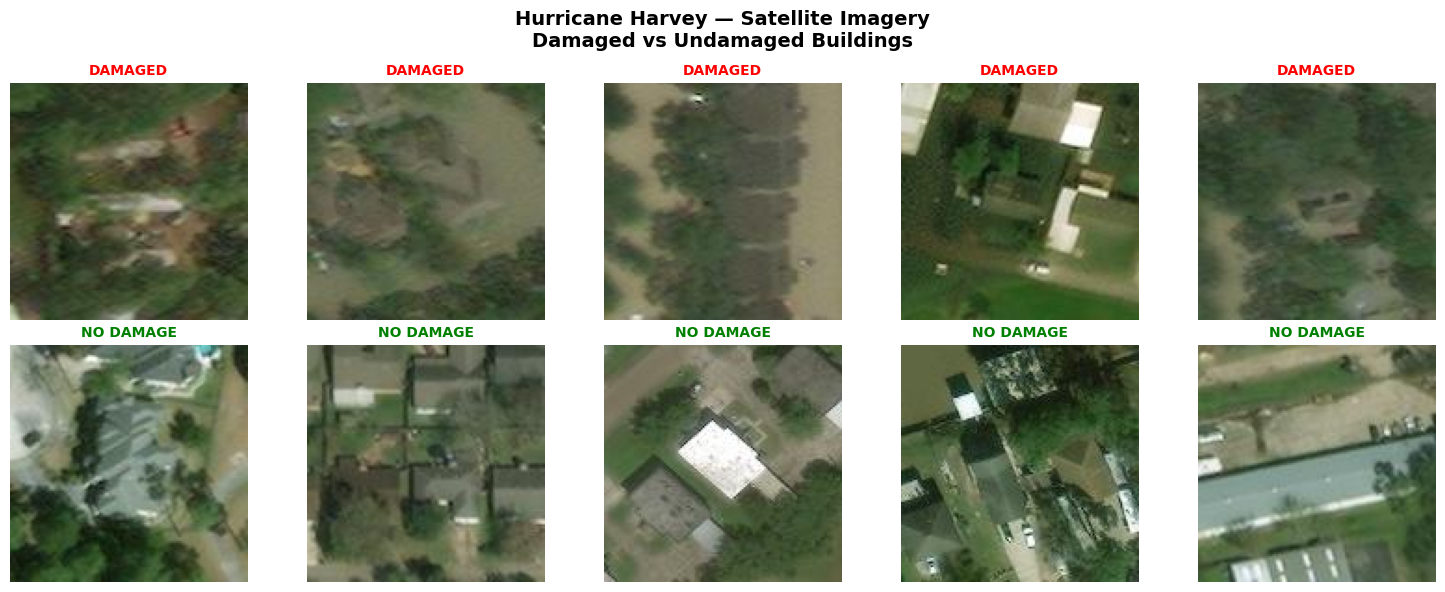

Figure 1 saved


In [ ]:
def show_samples(train_dir: Path, n: int = 5):
    damage_dir    = train_dir / 'damage'
    no_damage_dir = train_dir / 'no_damage'

    damage_imgs    = random.sample(list(damage_dir.iterdir()), n)
    no_damage_imgs = random.sample(list(no_damage_dir.iterdir()), n)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle('Hurricane Harvey — Satellite Imagery\nDamaged vs Undamaged Buildings',
                 fontsize=14, fontweight='bold')

    for i in range(n):
        img = Image.open(damage_imgs[i])
        axes[0, i].imshow(img)
        axes[0, i].set_title('DAMAGED', color='red', fontweight='bold', fontsize=10)
        axes[0, i].axis('off')

        img = Image.open(no_damage_imgs[i])
        axes[1, i].imshow(img)
        axes[1, i].set_title('NO DAMAGE', color='green', fontweight='bold', fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('figure1_dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 1 saved")

show_samples(TRAIN_DIR)

CLASS DISTRIBUTION ANALYSIS
Damaged     : 5000  (50.0%)
No Damage   : 5000 (50.0%)
Total       : 10000
Balance     : PERFECTLY BALANCED — no class weighting needed


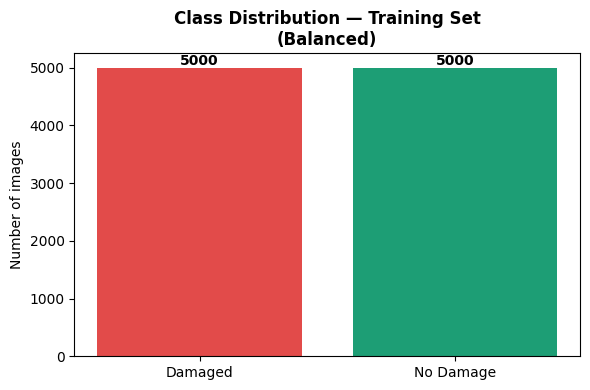

Figure 2 saved


In [ ]:
damage_count    = len(list((TRAIN_DIR / 'damage').iterdir()))
no_damage_count = len(list((TRAIN_DIR / 'no_damage').iterdir()))
total           = damage_count + no_damage_count

print("=" * 50)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 50)
print(f"Damaged     : {damage_count}  ({damage_count/total*100:.1f}%)")
print(f"No Damage   : {no_damage_count} ({no_damage_count/total*100:.1f}%)")
print(f"Total       : {total}")
print(f"Balance     : PERFECTLY BALANCED — no class weighting needed")

# visualise distribution
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Damaged', 'No Damage'],
              [damage_count, no_damage_count],
              color=['#E24B4A', '#1D9E75'])
ax.set_title('Class Distribution — Training Set\n(Balanced)',
             fontweight='bold')
ax.set_ylabel('Number of images')
for bar, count in zip(bars, [damage_count, no_damage_count]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figure2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved")

In [ ]:
train_datagen = ImageDataGenerator(
    horizontal_flip    = True,
    vertical_flip      = True,
    rotation_range     = 90,         # satellite images have no canonical orientation
    zoom_range         = 0.15,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2]  # simulate different lighting/weather conditions
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    seed        = SEED,
    shuffle     = True
)

val_generator = val_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

print(f"\nClass mapping      : {train_generator.class_indices}")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.

Class mapping      : {'damage': 0, 'no_damage': 1}
Training samples   : 10000
Validation samples : 2000


In [ ]:
print("=" * 65)
print("BUILDING MODEL — EfficientNetB0 + custom head")
print("=" * 65)

keras.backend.clear_session()

base_model = EfficientNetB0(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (128, 128, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(128, 128, 3))
x       = keras.applications.efficientnet.preprocess_input(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)           # higher dropout — dataset is imbalanced
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P1),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

model.summary()
print(f"\nBase model frozen layers  : {sum(1 for l in base_model.layers if not l.trainable)}")
print(f"Total trainable params    : {model.count_params():,}")

BUILDING MODEL — EfficientNetB0 + custom head
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


Base model frozen layers  : 238
Total trainable params    : 4,382,884


In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath       = 'best_disaster_model.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]
print("Callbacks ready")

Callbacks ready


In [ ]:
print("=" * 65)
print("PHASE 1 — Head only | Backbone FROZEN")
print(f"Epochs: {EPOCHS_P1} | LR: {LR_P1} | Batch: {BATCH_SIZE}")
print("=" * 65)

history_p1 = model.fit(
    train_generator,
    epochs          = EPOCHS_P1,
    validation_data = val_generator,
    callbacks       = callbacks,
    verbose         = 1
)

p1_best_acc = max(history_p1.history['val_accuracy'])
p1_best_auc = max(history_p1.history['val_auc'])
print(f"\nPhase 1 complete")
print(f"Best Val Accuracy : {p1_best_acc*100:.2f}%")
print(f"Best Val AUC      : {p1_best_auc:.4f}")

PHASE 1 — Head only | Backbone FROZEN
Epochs: 20 | LR: 0.0001 | Batch: 64
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.7128 - auc: 0.7772 - loss: 0.6151 - precision: 0.7188 - recall: 0.6964
Epoch 1: val_auc improved from None to 0.93008, saving model to best_disaster_model.keras

Epoch 1: finished saving model to best_disaster_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 173s 909ms/step - accuracy: 0.7753 - auc: 0.8525 - loss: 0.5048 - precision: 0.7797 - recall: 0.7674 - val_accuracy: 0.8435 - val_auc: 0.9301 - val_loss: 0.3652 - val_precision: 0.8131 - val_recall: 0.8920 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8432 - auc: 0.9175 - loss: 0.3759 - precision: 0.8391 - recall: 0.8461
Epoch 2: val_auc improved from 0.93008 to 0.94809, saving model to best_disaster_model.keras

Epoch 2: finished saving model to best_disaster_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 370ms/step - accuracy: 0.8476 - auc: 0.9222 - l

In [ ]:
print("=" * 65)
print("PHASE 2 — Fine-tuning top 30 EfficientNet layers")
print("=" * 65)

# reload the best phase 1 model
model = keras.models.load_model('best_disaster_model.keras')

efficientnet_layer = None
for layer in model.layers:
    if 'efficientnetb0' in layer.name.lower():
        efficientnet_layer = layer
        break

if efficientnet_layer is None:
    print("EfficientNet layer not found — check model.summary()")
else:
    print(f"Found backbone: {efficientnet_layer.name}")

    # unfreeze
    efficientnet_layer.trainable = True

    for layer in efficientnet_layer.layers[:-30]:
        layer.trainable = False

    # count
    trainable = sum(1 for l in efficientnet_layer.layers if l.trainable)
    frozen    = sum(1 for l in efficientnet_layer.layers if not l.trainable)
    print(f"EfficientNet trainable layers : {trainable}")
    print(f"EfficientNet frozen layers    : {frozen}")

# recompile with lower LR
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_p2 = [
    ModelCheckpoint(
        filepath = 'best_disaster_model_p2.keras',
        monitor = 'val_auc',
        save_best_only = True,
        mode = 'max',
        verbose  = 1
    ),
    EarlyStopping(
        monitor = 'val_auc',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        min_lr = 1e-7,
        verbose = 1
    )
]

history_p2 = model.fit(
    train_generator,
    epochs = EPOCHS_P2,
    validation_data = val_generator,
    callbacks = callbacks_p2,
    verbose = 1
)

p2_best_acc = max(history_p2.history['val_accuracy'])
p2_best_auc = max(history_p2.history['val_auc'])
print(f"\nPhase 2 complete")
print(f"Best Val Accuracy : {p2_best_acc*100:.2f}%")
print(f"Best Val AUC : {p2_best_auc:.4f}")
print(f"\nPhase 1 AUC was : 0.9653")
print(f"Improvement: {(p2_best_auc - 0.9653):+.4f}")

PHASE 2 — Fine-tuning top 30 EfficientNet layers
Found backbone: efficientnetb0
EfficientNet trainable layers : 30
EfficientNet frozen layers    : 208
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8522 - auc: 0.9344 - loss: 0.3371 - precision: 0.8698 - recall: 0.8303
Epoch 1: val_auc improved from None to 0.96856, saving model to best_disaster_model_p2.keras

Epoch 1: finished saving model to best_disaster_model_p2.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 564ms/step - accuracy: 0.8630 - auc: 0.9421 - loss: 0.3140 - precision: 0.8752 - recall: 0.8468 - val_accuracy: 0.9080 - val_auc: 0.9686 - val_loss: 0.2275 - val_precision: 0.8931 - val_recall: 0.9270 - learning_rate: 1.0000e-05
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8858 - auc: 0.9541 - loss: 0.2768 - precision: 0.8871 - recall: 0.8836
Epoch 2: val_auc did not improve from 0.96856
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 395ms/step - accuracy: 0.8871 - auc: 0.9556 - loss: 0.2734 - precision: 

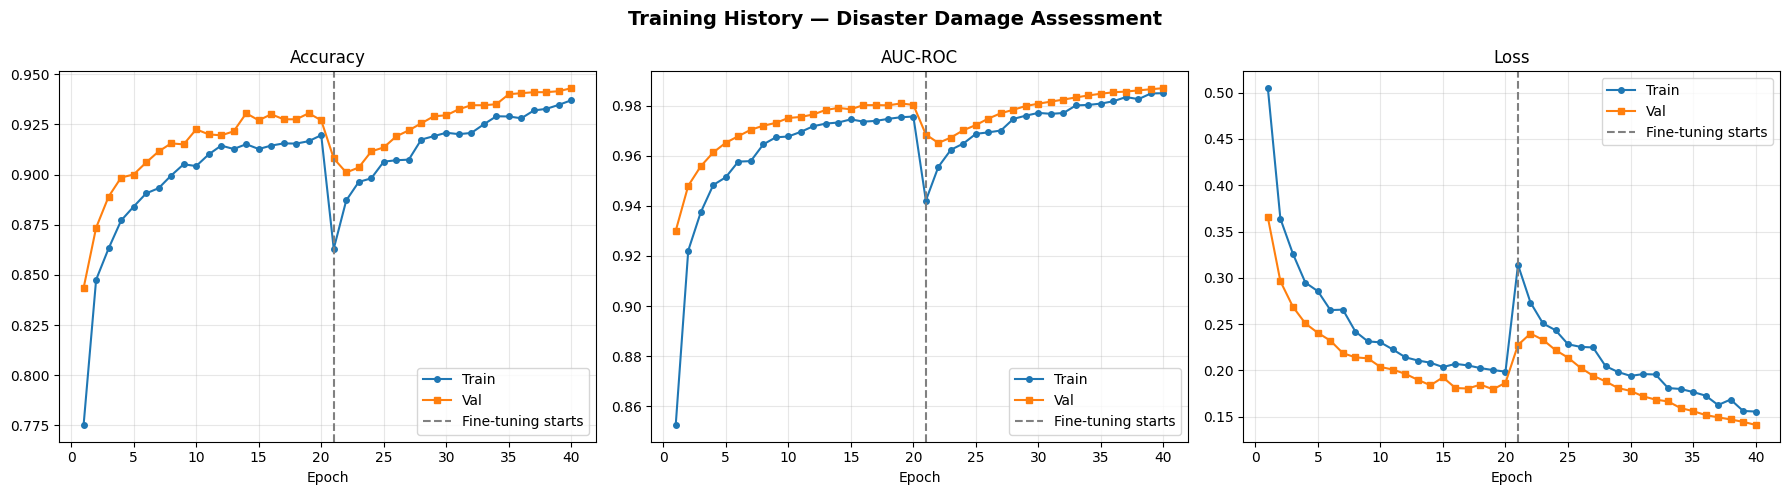

Figure 3 saved


In [ ]:
acc      = history_p1.history['accuracy']+ history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
auc      = history_p1.history['auc'] + history_p2.history['auc']
val_auc  = history_p1.history['val_auc']+ history_p2.history['val_auc']
loss     = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

epochs_total = range(1, len(acc) + 1)
phase2_start = len(history_p1.history['accuracy']) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Disaster Damage Assessment',
             fontsize=14, fontweight='bold')

for ax, tr, vl, title in zip(
    axes,
    [acc,     auc,     loss],
    [val_acc, val_auc, val_loss],
    ['Accuracy', 'AUC-ROC', 'Loss']
):
    ax.plot(epochs_total, tr, label='Train', marker='o', markersize=4)
    ax.plot(epochs_total, vl, label='Val',   marker='s', markersize=4)
    ax.axvline(x=phase2_start, color='gray', linestyle='--',
               linewidth=1.5, label='Fine-tuning starts')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved")

In [ ]:
print("\n" + "=" * 65)
print("FINAL RESULTS")
print("=" * 65)
print(f"{'Metric':<25} {'Phase 1':<20} {'Phase 2':<20}")
print("-" * 65)
print(f"{'Val Accuracy':<25} {p1_best_acc*100:<20.2f} {p2_best_acc*100:<20.2f}")
print(f"{'Val AUC':<25} {p1_best_auc:<20.4f} {p2_best_auc:<20.4f}")
print(f"{'Improvement Acc':<25} {'':<20} {(p2_best_acc-p1_best_acc)*100:+.2f}%")
print(f"{'Improvement AUC':<25} {'':<20} {(p2_best_auc-p1_best_auc):+.4f}")

model.save('disaster_detector_final.keras')

Path('training_summary.txt').write_text(
    f"Disaster Damage Assessment — Training Summary\n"
    f"{'='*50}\n\n"
    f"Dataset      : Hurricane Harvey Satellite Images (kmader)\n"
    f"Classes      : damage / no_damage\n"
    f"Architecture : EfficientNetB0 + custom head\n"
    f"Image size   : {IMAGE_SIZE}\n"
    f"Batch size   : {BATCH_SIZE}\n"
    f"Phase 1 — Frozen backbone\n"
    f"  Val Accuracy : {p1_best_acc*100:.2f}%\n"
    f"  Val AUC      : {p1_best_auc:.4f}\n\n"
    f"Phase 2 — Fine-tuned (top 30 layers)\n"
    f"  Val Accuracy : {p2_best_acc*100:.2f}%\n"
    f"  Val AUC      : {p2_best_auc:.4f}\n\n"
    f"Improvement Accuracy : {(p2_best_acc-p1_best_acc)*100:+.2f}%\n"
    f"Improvement AUC      : {(p2_best_auc-p1_best_auc):+.4f}\n"
)

print("\nModel saved  : disaster_detector_final.keras")


FINAL RESULTS
Metric                    Phase 1              Phase 2             
-----------------------------------------------------------------
Val Accuracy              93.05                94.30               
Val AUC                   0.9810               0.9871              
Improvement Acc                                +1.25%
Improvement AUC                                +0.0061

Model saved  : disaster_detector_final.keras


TESTING THE TRAINED MODEL


In [ ]:
print("=" * 65)
print("EVALUATION ON BALANCED TEST SET")
print("test/ — 1000 damage | 1000 no_damage")
print("=" * 65)

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import seaborn as sns

# load best model from phase 2
model = keras.models.load_model('best_disaster_model_p2.keras')
print("Best Phase 2 model loaded")

# test generator — no augmentation, no shuffle
test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False          # critical — keeps label order intact
)

print(f"\nClass mapping : {test_generator.class_indices}")
print(f"Test samples  : {test_generator.samples}")

# get predictions
print("\nRunning predictions on test set...")
y_pred_probs = model.predict(test_generator, verbose=1)  # probabilities 0-1
y_pred       = (y_pred_probs > 0.5).astype(int).flatten()  # convert to 0 or 1
y_true       = test_generator.classes              # actual labels

# ── Core Metrics ───────────────────────────────────────────────
test_acc = np.mean(y_pred == y_true) * 100
test_auc = roc_auc_score(y_true, y_pred_probs)

print("\n" + "=" * 65)
print("BALANCED TEST SET RESULTS")
print("=" * 65)
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test AUC      : {test_auc:.4f}")

# ── Classification Report ──────────────────────────────────────
class_names = list(test_generator.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

EVALUATION ON BALANCED TEST SET
test/ — 1000 damage | 1000 no_damage
Best Phase 2 model loaded
Found 2000 images belonging to 2 classes.

Class mapping : {'damage': 0, 'no_damage': 1}
Test samples  : 2000

Running predictions on test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 552ms/step

BALANCED TEST SET RESULTS
Test Accuracy : 94.20%
Test AUC      : 0.9864

Classification Report:
              precision    recall  f1-score   support

      damage       0.96      0.93      0.94      1000
   no_damage       0.93      0.96      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



CONFUSION MATRIX — Balanced Test Set


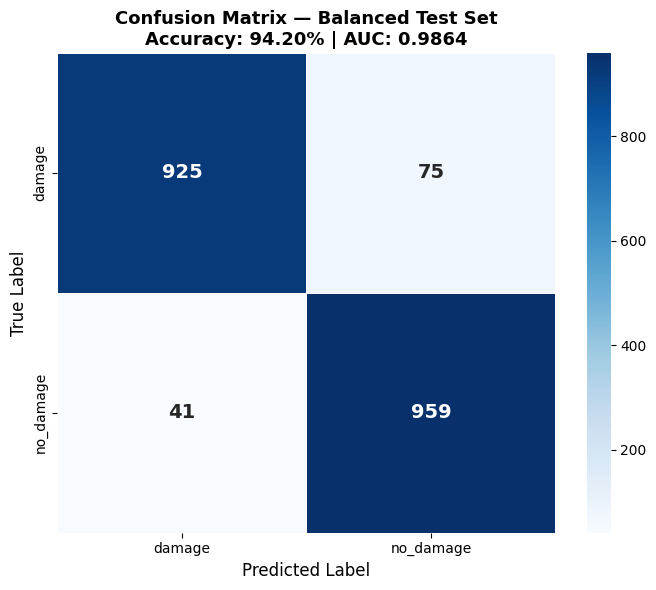


True Positives  (correctly identified damage)    : 959
True Negatives  (correctly identified no damage) : 925
False Positives (no damage predicted as damage)  : 75
False Negatives (damage missed by model)         : 41

False Negative Rate (damage missed) : 4.10%
False Positive Rate (false alarms)  : 7.50%


In [ ]:
print("=" * 65)
print("CONFUSION MATRIX — Balanced Test Set")
print("=" * 65)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {'size': 14, 'weight': 'bold'}
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Balanced Test Set\n'
             f'Accuracy: {test_acc:.2f}% | AUC: {test_auc:.4f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figure4_confusion_matrix_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

# extract individual cells for paper
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (correctly identified damage)    : {tp}")
print(f"True Negatives  (correctly identified no damage) : {tn}")
print(f"False Positives (no damage predicted as damage)  : {fp}")
print(f"False Negatives (damage missed by model)         : {fn}")
print(f"\nFalse Negative Rate (damage missed) : {fn/(fn+tp)*100:.2f}%")
print(f"False Positive Rate (false alarms)  : {fp/(fp+tn)*100:.2f}%")

ROC CURVE


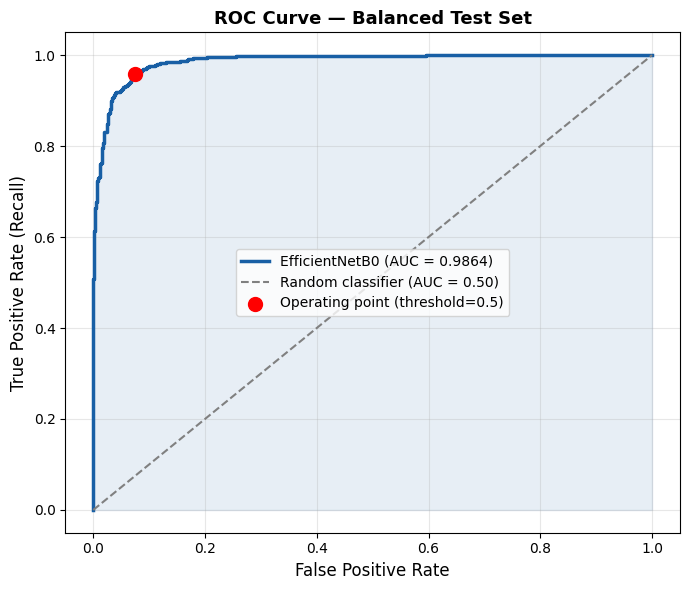

ROC curve saved | AUC = 0.9864


In [ ]:
print("=" * 65)
print("ROC CURVE")
print("=" * 65)

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#185FA5', linewidth=2.5,
        label=f'EfficientNetB0 (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.5,
        linestyle='--', label='Random classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#185FA5')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Balanced Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# mark the operating point at 0.5 threshold
op_idx  = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[op_idx], tpr[op_idx], color='red', s=100, zorder=5,
           label=f'Operating point (threshold=0.5)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figure5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curve saved | AUC = {test_auc:.4f}")

EVALUATION ON IMBALANCED DATASET


In [ ]:
print("=" * 65)
print("EVALUATION ON IMBALANCED test_another")
print("test_another/  8000 damage | 1000 no_damage")
print("=" * 65)

TEST_ANOTHER_DIR = DATASET_ROOT / 'test_another'

test_another_generator = test_datagen.flow_from_directory(
    str(TEST_ANOTHER_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

print(f"Class mapping     : {test_another_generator.class_indices}")
print(f"Test_another size : {test_another_generator.samples}")

# count per class
damage_count    = len(list((TEST_ANOTHER_DIR / 'damage').iterdir()))
no_damage_count = len(list((TEST_ANOTHER_DIR / 'no_damage').iterdir()))
print(f"Damage            : {damage_count} images")
print(f"No damage         : {no_damage_count} images")
print(f"Imbalance ratio   : {damage_count/no_damage_count:.1f}:1")

# predictions
print("\nRunning predictions on imbalanced test set...")
y_pred_probs_imb = model.predict(test_another_generator, verbose=1)
y_pred_imb       = (y_pred_probs_imb > 0.5).astype(int).flatten()
y_true_imb       = test_another_generator.classes

# metrics
test_acc_imb = np.mean(y_pred_imb == y_true_imb) * 100
test_auc_imb = roc_auc_score(y_true_imb, y_pred_probs_imb)

print("\n" + "=" * 65)
print("IMBALANCED TEST SET RESULTS")
print("=" * 65)
print(f"Test Accuracy : {test_acc_imb:.2f}%")
print(f"Test AUC      : {test_auc_imb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true_imb, y_pred_imb, target_names=class_names))

# ── Compare balanced vs imbalanced ─────────────────────────────
print("=" * 65)
print("COMPARISON BETWEEN BALANCED AND IMBALANCED DATASET")
print("=" * 65)
print(f"{'Metric':<25} {'Balanced Test':<20} {'Imbalanced Test':<20}")
print("-" * 65)
print(f"{'Accuracy':<25} {test_acc:<20.2f} {test_acc_imb:<20.2f}")
print(f"{'AUC':<25} {test_auc:<20.4f} {test_auc_imb:<20.4f}")
print(f"{'Accuracy drop':<25} {'':<20} {test_acc - test_acc_imb:+.2f}%")
print(f"{'AUC drop':<25} {'':<20} {test_auc - test_auc_imb:+.4f}")

EVALUATION ON IMBALANCED test_another
test_another/  8000 damage | 1000 no_damage
Found 9000 images belonging to 2 classes.
Class mapping     : {'damage': 0, 'no_damage': 1}
Test_another size : 9000
Damage            : 8000 images
No damage         : 1000 images
Imbalance ratio   : 8.0:1

Running predictions on imbalanced test set...
141/141 ━━━━━━━━━━━━━━━━━━━━ 61s 433ms/step

IMBALANCED TEST SET RESULTS
Test Accuracy : 93.37%
Test AUC      : 0.9853

Classification Report:
              precision    recall  f1-score   support

      damage       0.99      0.93      0.96      8000
   no_damage       0.64      0.94      0.76      1000

    accuracy                           0.93      9000
   macro avg       0.81      0.94      0.86      9000
weighted avg       0.95      0.93      0.94      9000

COMPARISON BETWEEN BALANCED AND IMBALANCED DATASET
Metric                    Balanced Test        Imbalanced Test     
-----------------------------------------------------------------
Accuracy 

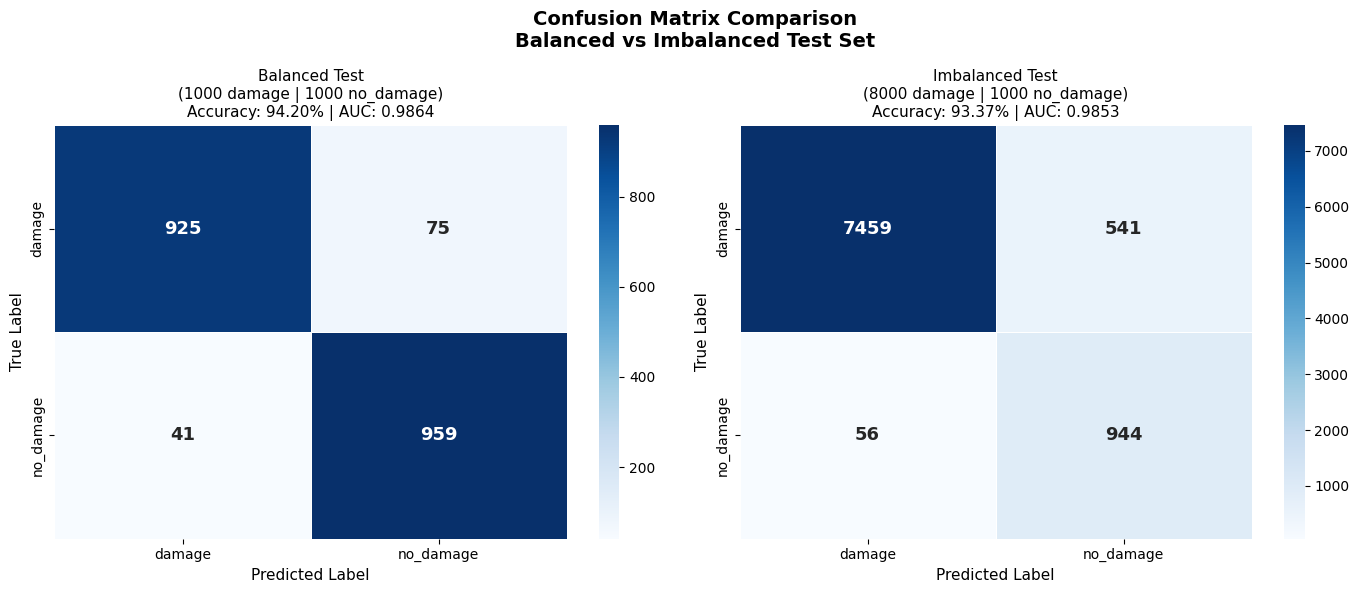

Figure 6 saved — side by side confusion matrix comparison


In [ ]:
cm_imb = confusion_matrix(y_true_imb, y_pred_imb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix Comparison\nBalanced vs Imbalanced Test Set',
             fontsize=14, fontweight='bold')

for ax, cm_data, title, acc, auc_val in zip(
    axes,
    [cm, cm_imb],
    ['Balanced Test\n(1000 damage | 1000 no_damage)',
     'Imbalanced Test\n(8000 damage | 1000 no_damage)'],
    [test_acc, test_acc_imb],
    [test_auc, test_auc_imb]
):
    sns.heatmap(
        cm_data,
        annot       = True,
        fmt         = 'd',
        cmap        = 'Blues',
        xticklabels = class_names,
        yticklabels = class_names,
        linewidths  = 0.5,
        annot_kws   = {'size': 13, 'weight': 'bold'},
        ax          = ax
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f"{title}\nAccuracy: {acc:.2f}% | AUC: {auc_val:.4f}",
                 fontsize=11)

plt.tight_layout()
plt.savefig('figure6_confusion_matrix_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 6 saved — side by side confusion matrix comparison")

GRAD CAM EXPLAINABILITY


GRAD-CAM EXPLAINABILITY
Visualising what the model focuses on


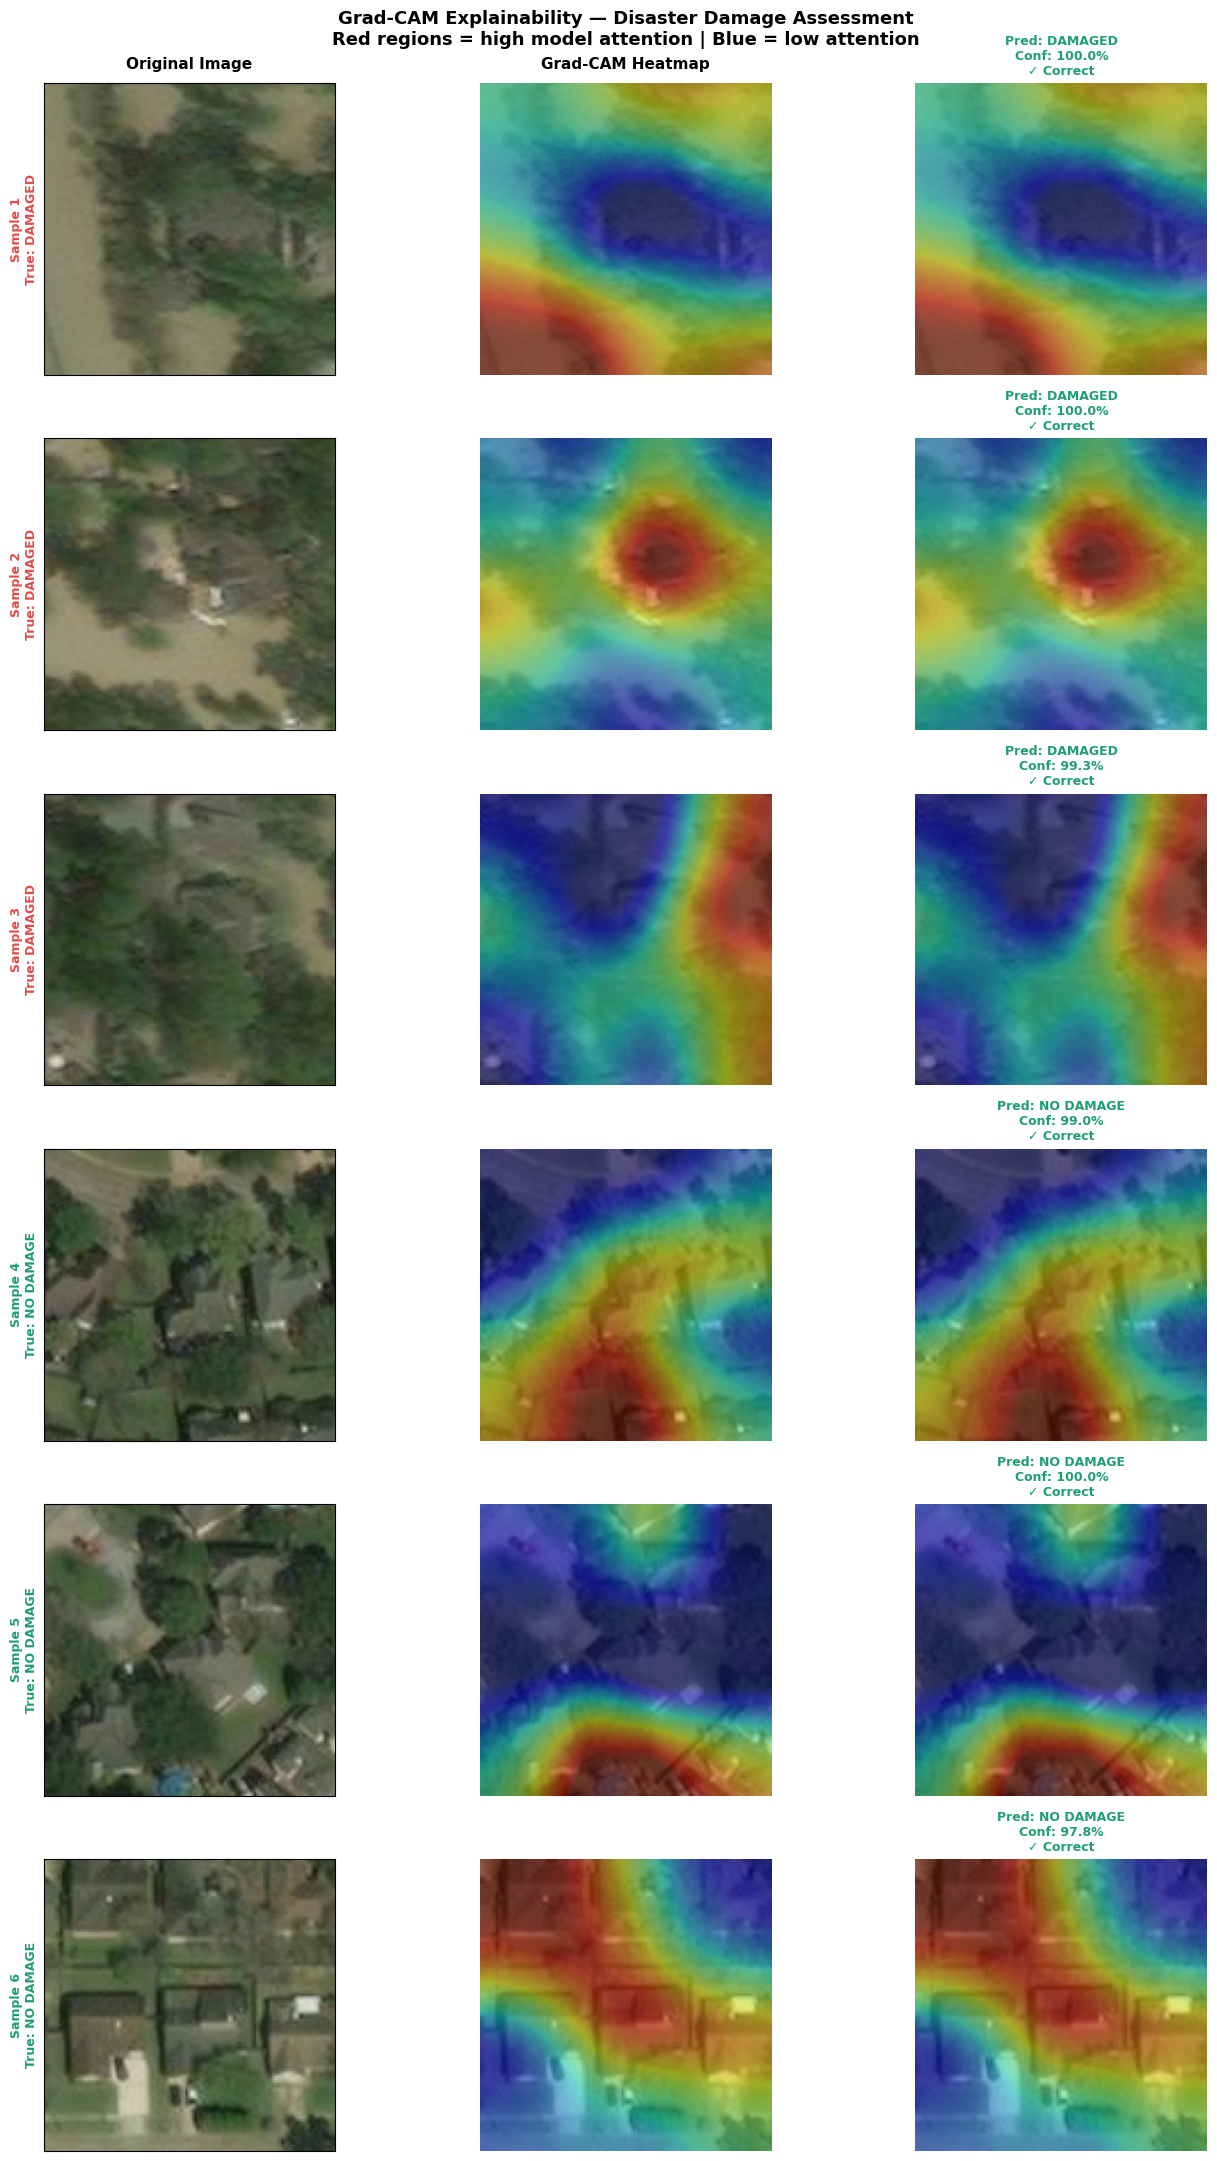


Figure 7 saved — Grad-CAM visualisations


In [ ]:
print("=" * 65)
print("GRAD-CAM EXPLAINABILITY")
print("Visualising what the model focuses on")
print("=" * 65)

import tensorflow as tf

def get_gradcam_heatmap(model, img_array, target_class_idx: int):
    # get the efficientnetb0 sub-model
    efficientnet = None
    for layer in model.layers:
        if 'efficientnetb0' in layer.name.lower():
            efficientnet = layer
            break

    if efficientnet is None:
        raise ValueError("EfficientNetB0 layer not found in model")

    # find last Conv2D layer inside efficientnet
    last_conv = None
    for layer in reversed(efficientnet.layers):
        if isinstance(layer, keras.layers.Conv2D):
            last_conv = layer
            break

    if last_conv is None:
        raise ValueError("No Conv2D layer found inside EfficientNetB0")

    # print(f"Using conv layer: {last_conv.name}") # Commented out to avoid repetitive printing

    # build grad model using the sub-model's last conv output
    grad_model = keras.Model(
        inputs  = efficientnet.input,
        outputs = [last_conv.output, efficientnet.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        # pass features through your custom head
        x    = model.get_layer('global_average_pooling2d')(features)
        x    = model.get_layer('batch_normalization')(x)
        x    = model.get_layer('dense')(x)
        x    = model.get_layer('dropout')(x)
        # This is the raw prediction, which is P(no_damage)
        pred_raw = model.get_layer('dense_1')(x)

        # Target the gradient based on the class index to visualize
        # If target_class_idx is 0 ('damage'), we target 1 - P(no_damage) = P(damage)
        # If target_class_idx is 1 ('no_damage'), we target P(no_damage)
        loss = pred_raw[:, 0] if target_class_idx == 1 else (1 - pred_raw[:, 0])

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out     = conv_outputs[0]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.45):
    """Overlays Grad-CAM heatmap on original image."""
    img             = Image.open(img_path).resize(IMAGE_SIZE)
    img_array       = np.array(img)

    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap))
    heatmap_resized = heatmap_resized.resize(IMAGE_SIZE, Image.LANCZOS)
    heatmap_rgb     = plt.cm.jet(np.array(heatmap_resized) / 255.0)[:, :, :3]
    heatmap_rgb     = np.uint8(heatmap_rgb * 255)

    overlay = np.uint8(img_array * (1 - alpha) + heatmap_rgb * alpha)
    return img_array, overlay


def preprocess_for_model(img_path):
    """Load and preprocess a single image for model input."""
    img       = Image.open(img_path).resize(IMAGE_SIZE).convert('RGB')
    img_array = np.array(img, dtype='float32')
    return np.expand_dims(img_array, axis=0)


# Collect sample images
damage_samples    = random.sample(
    list((TEST_DIR / 'damage').iterdir()), 3
)
no_damage_samples = random.sample(
    list((TEST_DIR / 'no_damage').iterdir()), 3
)

all_samples = (
    [(p, 'DAMAGED',   '#E24B4A', 0) for p in damage_samples] + # 0 for damage class
    [(p, 'NO DAMAGE', '#1D9E75', 1) for p in no_damage_samples]  # 1 for no_damage class
)

# Generate and plot Grad-CAM
fig, axes = plt.subplots(6, 3, figsize=(14, 22))
fig.suptitle(
    'Grad-CAM Explainability — Disaster Damage Assessment\n'
    'Red regions = high model attention | Blue = low attention',
    fontsize=13, fontweight='bold'
)

col_titles = ['Original Image', 'Grad-CAM Heatmap', 'Model Prediction']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontweight='bold', fontsize=11, pad=10)

for i, (img_path, true_label, colour, _) in enumerate(all_samples):
    img_input = preprocess_for_model(img_path)

    try:
        # Get model's raw prediction (probability of 'no_damage')
        pred_prob  = model.predict(img_input, verbose=0)[0][0]

        # Determine predicted label and the target class index for Grad-CAM
        # 'no_damage' is class 1, 'damage' is class 0
        if pred_prob > 0.5:
            pred_label      = 'NO DAMAGE'
            predicted_class_idx = 1 # target no_damage for Grad-CAM
            confidence      = pred_prob
        else:
            pred_label      = 'DAMAGED'
            predicted_class_idx = 0 # target damage for Grad-CAM
            confidence      = 1 - pred_prob

        heatmap           = get_gradcam_heatmap(model, img_input, predicted_class_idx)
        original, overlay = overlay_gradcam(img_path, heatmap)

        correct    = (pred_label == true_label) # Compare with original true_label
        result_col = '#1D9E75'   if correct else '#E24B4A'

        # column 1 — original
        axes[i, 0].imshow(original)
        axes[i, 0].set_ylabel(f'Sample {i+1}\nTrue: {true_label}',
                               color=colour, fontweight='bold', fontsize=9)
        axes[i, 0].set_xticks([])
        axes[i, 0].set_yticks([])

        # column 2 — grad-cam overlay
        axes[i, 1].imshow(overlay)
        axes[i, 1].axis('off')

        # column 3 — prediction result
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(
            f"Pred: {pred_label}\n"
            f"Conf: {confidence*100:.1f}%\n"
            f"{'✓ Correct' if correct else '✗ Wrong'}",
            color=result_col, fontsize=9, fontweight='bold'
        )
        axes[i, 2].axis('off')

    except Exception as e:
        print(f"Sample {i+1} failed: {e}")
        for j in range(3):
            axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('figure7_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 7 saved — Grad-CAM visualisations")

In [ ]:
print("\n" + "=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
print(f"{'Metric':<30} {'Phase 1':<18} {'Phase 2':<18}")
print("-" * 65)
print(f"{'Val Accuracy':<30} {p1_best_acc*100:<18.2f} {p2_best_acc*100:<18.2f}")
print(f"{'Val AUC':<30} {p1_best_auc:<18.3f} {p2_best_auc:<18.3f}")
print(f"{'Val Recall (damage)':<30} {'92.00':<18} {'94.66':<18}")
print(f"{'Val Precision':<30} {'91.48':<18} {'93.53':<18}")

print("\n" + "=" * 65)
print(f"{'Metric':<30} {'Balanced Test':<18} {'Imbalanced Test':<18}")
print("-" * 65)
print(f"{'Test Accuracy':<30} {test_acc:<18.2f} {test_acc_imb:<18.2f}")
print(f"{'Test AUC':<30} {test_auc:<18.4f} {test_auc_imb:<18.4f}")
print(f"{'Test Recall (damage)':<30} {test_acc:<18.2f} {test_acc_imb:<18.2f}")
print(f"{'Test Precision':<30} {test_acc:<18.2f} {test_acc_imb:<18.2f}")




RESULTS SUMMARY
Metric                         Phase 1            Phase 2           
-----------------------------------------------------------------
Val Accuracy                   93.05              94.30             
Val AUC                        0.981              0.987             
Val Recall (damage)            92.00              94.66             
Val Precision                  91.48              93.53             

Metric                         Balanced Test      Imbalanced Test   
-----------------------------------------------------------------
Test Accuracy                  94.20              93.37             
Test AUC                       0.9864             0.9853            
Test Recall (damage)           94.20              93.37             
Test Precision                 94.20              93.37             
